# Sleep Disorder and Stress Level Prediction
**Objective:** To analyze lifestyle factors such as stress levels, sleep duration, and daily physical activity to predict the presence of sleep disorders using Machine Learning.

**Author:** [Shivam Kumar / ShivamKumar9234]

In [2]:
!pip install gdown
import gdown

file_id = '1DfJ6M4WU_yjlOk-_lZg2JCaWHlaszH6U' 
url = f'https://drive.google.com/uc?id={file_id}'

output = 'dataset.csv'
gdown.download(url, output, quiet=False)

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1DfJ6M4WU_yjlOk-_lZg2JCaWHlaszH6U
To: c:\Users\shiva\OneDrive\Desktop\ML-CaPsule\Sleep_Disorder_Prediction\dataset.csv
100%|██████████| 24.1k/24.1k [00:00<00:00, 556kB/s]


'dataset.csv'

In [3]:
# ==========================================
# 1. IMPORTING NECESSARY LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualization
sns.set_theme(style="whitegrid")

# ==========================================
# 2. DATA LOADING
# ==========================================
# Load the dataset into a Pandas DataFrame
try:
    df = pd.read_csv('dataset.csv')
    print("Dataset loaded successfully!")
    print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns.\n")
except FileNotFoundError:
    print("Error: The file 'dataset.csv' was not found. Please check the directory.")

# Display the first 5 rows of the dataset
df.head()

Dataset loaded successfully!
Dataset Shape: 374 rows and 13 columns.



,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
# ==========================================
# 3. DATA INSPECTION & BASIC CLEANING
# ==========================================

# Display general information about the dataset (data types, non-null counts)
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Check ---")
# Check for any missing/null values in each column
missing_values = df.isnull().sum()
print(missing_values)

# Display statistical summary of numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB

--- Miss

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


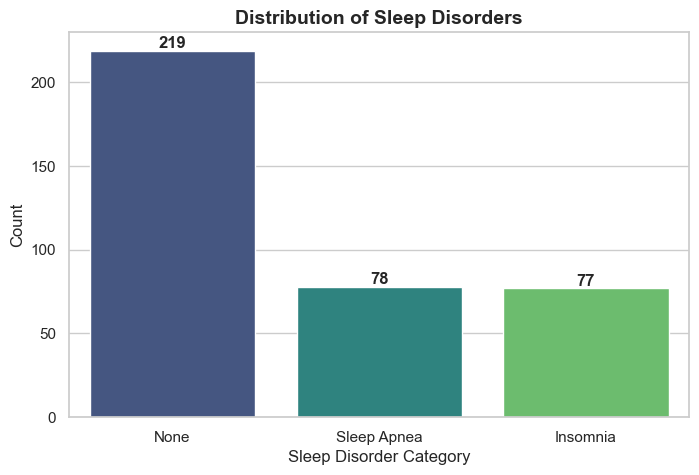

In [5]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

# Analyzing the Target Variable: 'Sleep Disorder'
# Fill missing values in Target Variable with 'None' if any exist
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# Create a figure for the plot
plt.figure(figsize=(8, 5))

# Plot the distribution of sleep disorders
ax = sns.countplot(data=df, x='Sleep Disorder', palette='viridis', order=df['Sleep Disorder'].value_counts().index)

# Add titles and labels
plt.title('Distribution of Sleep Disorders', fontsize=14, fontweight='bold')
plt.xlabel('Sleep Disorder Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add value counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Show the plot
plt.show()

In [6]:
# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================

# Split 'Blood Pressure' into two separate numerical columns: 'Systolic_BP' and 'Diastolic_BP'
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)

# Drop the original 'Blood Pressure' column and 'Person ID' (as it's just an index)
df = df.drop(columns=['Blood Pressure', 'Person ID'])

print("Feature Engineering Completed! ✅")
print("New Columns in Dataset:\n", df.columns.tolist())

Feature Engineering Completed! ✅
New Columns in Dataset:
 ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps', 'Sleep Disorder', 'Systolic_BP', 'Diastolic_BP']


In [7]:
# ==========================================
# 6. DATA ENCODING
# ==========================================
from sklearn.preprocessing import LabelEncoder

# 1. Encode Target Variable ('Sleep Disorder') using LabelEncoder
le = LabelEncoder()
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])

# Print what number represents what category
print("Target Encoding Mapping:")
for i, item in enumerate(le.classes_):
    print(f"'{item}' is encoded as {i}")

# 2. Convert other categorical columns using One-Hot Encoding (pd.get_dummies)
df = pd.get_dummies(df, columns=['Gender', 'Occupation', 'BMI Category'], drop_first=True)

print(f"\nShape of dataset after encoding: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())

Target Encoding Mapping:
'Insomnia' is encoded as 0
'None' is encoded as 1
'Sleep Apnea' is encoded as 2

Shape of dataset after encoding: 374 rows and 24 columns


,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,Diastolic_BP,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,1,126.0,83.0,...,False,False,False,False,False,True,False,False,False,True
1,28,6.2,6,60,8,75,10000,1,125.0,80.0,...,False,False,False,False,False,False,False,False,False,False
2,28,6.2,6,60,8,75,10000,1,125.0,80.0,...,False,False,False,False,False,False,False,False,False,False
3,28,5.9,4,30,8,85,3000,2,140.0,90.0,...,False,False,True,False,False,False,False,False,True,False
4,28,5.9,4,30,8,85,3000,2,140.0,90.0,...,False,False,True,False,False,False,False,False,True,False


In [8]:
# ==========================================
# 7. TRAIN-TEST SPLIT & SCALING
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate Features (X) and Target (y)
X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling (Standardization) to bring all numbers to a similar scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print("Data splitting and scaling completed! ✅")

Training data shape: (299, 23)
Testing data shape: (75, 23)
Data splitting and scaling completed! ✅


🌟 Model Accuracy: 88.00%

--- Classification Report ---
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



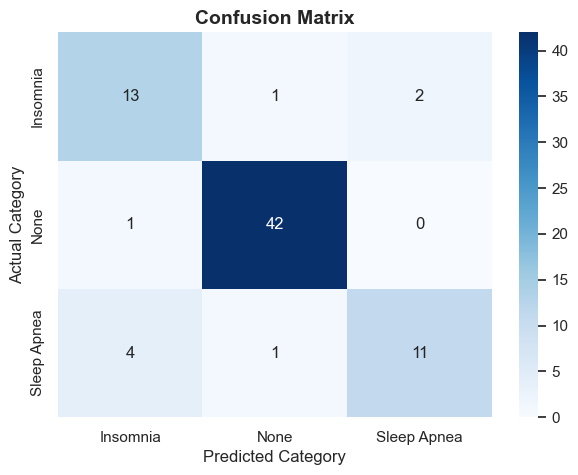

In [9]:
# ==========================================
# 8. MODEL TRAINING & EVALUATION
# ==========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"🌟 Model Accuracy: {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Plotting the Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Category', fontsize=12)
plt.xlabel('Predicted Category', fontsize=12)
plt.show()